# SVM - Grid optimization

In this notebook we try and find the optimized SVM to be used in our ensmble to further improve our results.

⚠️ Removing ultra-rare classes: ['LeftKneeMovesInward', 'LeftHeelRises', 'RightHeelRises']
Fitting 5 folds for each of 15 candidates, totalling 75 fits


/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packag


--- Top 10 SVC Parameter Combinations (Sorted by F1 Mean) ---
 rank_test_score  mean_test_score  std_test_score                                                   params
               1         0.602552        0.024343  {'svc__C': 5, 'svc__gamma': 0.02, 'svc__kernel': 'rbf'}
               2         0.600696        0.023575 {'svc__C': 4, 'svc__gamma': 0.025, 'svc__kernel': 'rbf'}
               3         0.598318        0.026379 {'svc__C': 6, 'svc__gamma': 0.015, 'svc__kernel': 'rbf'}
               4         0.594682        0.021696 {'svc__C': 5, 'svc__gamma': 0.025, 'svc__kernel': 'rbf'}
               5         0.593938        0.028987  {'svc__C': 6, 'svc__gamma': 0.02, 'svc__kernel': 'rbf'}
               6         0.593715        0.027349 {'svc__C': 5, 'svc__gamma': 0.015, 'svc__kernel': 'rbf'}
               7         0.592829        0.020913 {'svc__C': 6, 'svc__gamma': 0.025, 'svc__kernel': 'rbf'}
               8         0.592707        0.025118 {'svc__C': 3, 'svc__gamma': 0.0

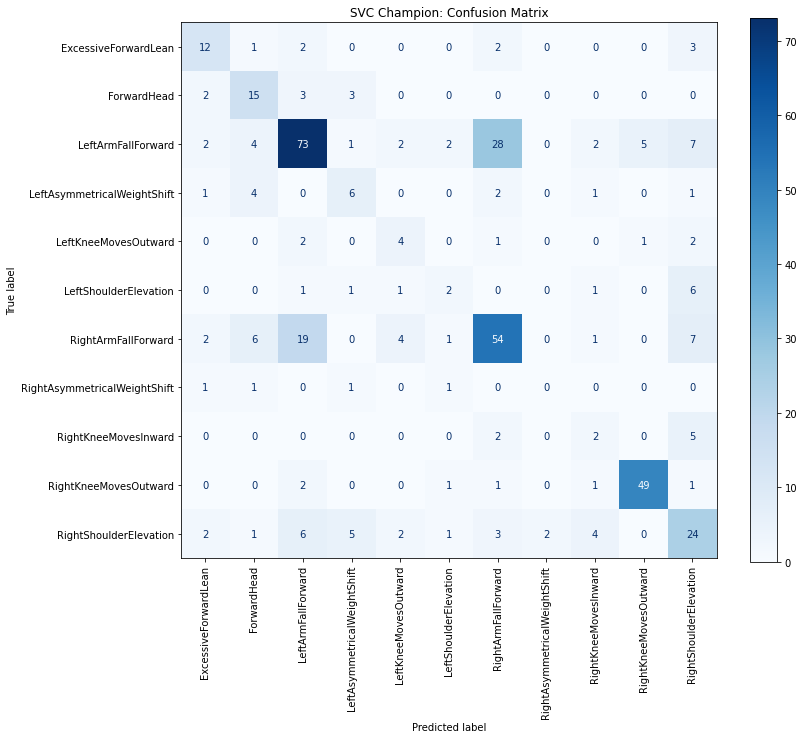

In [8]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter
import matplotlib.pyplot as plt

WeakLink_data_path = "../../data/AimoScore_WeakLink_big_scores_A3.csv"
Scores_data_path = "../../data/scores_and_weak_links_A3.csv"

dfw = pd.read_csv(WeakLink_data_path)
dfs = pd.read_csv(Scores_data_path)


df_final = pd.merge(dfw, dfs, on="ID")


weak_link_columns = [
    'ForwardHead', 'LeftArmFallForward', 'RightArmFallForward',
    'LeftShoulderElevation', 'RightShoulderElevation', 'ExcessiveForwardLean',
    'LeftAsymmetricalWeightShift', 'RightAsymmetricalWeightShift',
    'LeftKneeMovesInward', 'RightKneeMovesInward', 'LeftKneeMovesOutward',
    'RightKneeMovesOutward', 'LeftHeelRises', 'RightHeelRises'
]

df_final['WeakestLink'] = df_final[weak_link_columns].idxmax(axis=1)

# 1. Prepare Data (A3 Logic)
y = df_final['WeakestLink']
# Define columns to drop (cheating + non-numeric)
cheating_cols = weak_link_columns + ['WeakestLink', 'ID', 'Date', 'SCORE', 'AimoScore', 'EstimatedScore', 'label score']
X = df_final.drop(columns=[c for c in cheating_cols if c in df_final.columns], errors='ignore')
X = X.select_dtypes(include=[np.number])

# Filter ultra-rare classes to stabilize 5-fold CV
counts = y.value_counts()
rare_classes = counts[counts < 10].index
if len(rare_classes) > 0:
    print(f"⚠️ Removing ultra-rare classes: {list(rare_classes)}")
    mask = ~y.isin(rare_classes)
    X, y = X[mask], y[mask]

# Stratified split is crucial for classification!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2. Define the Pipeline with Oversampling
# We use ImbPipeline so oversampling only happens on training folds
strategy = {k: max(v, 50) for k, v in Counter(y_train).items()} # Floor of 50 samples

pipe = ImbPipeline([
    ('oversample', RandomOverSampler(sampling_strategy=strategy, random_state=42)),
    ('scaler', StandardScaler()),
    ('svc', SVC(probability=True, class_weight='balanced'))
])

# 3. Define the Parameter Grid
# We use RandomizedSearchCV because a full grid for SVC is very slow
refined_param_grid = {
    'svc__kernel': ['rbf'],
    'svc__C': [2, 3, 4, 5, 6],         # Testing values below 5
    'svc__gamma': [0.015, 0.02, 0.025], # Tightening around 0.02
}

# Now use GridSearchCV because the total combinations are small (~90)
final_grid = GridSearchCV(
    estimator=pipe,
    param_grid=refined_param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)


final_grid.fit(X_train, y_train)

# 5. Results & Top 10
results_df = pd.DataFrame(final_grid.cv_results_)
top_10 = results_df[['rank_test_score', 'mean_test_score', 'std_test_score', 'params']]
top_10 = top_10.sort_values(by='mean_test_score', ascending=False).head(10)

print("\n--- Top 10 SVC Parameter Combinations (Sorted by F1 Mean) ---")
print(top_10.to_string(index=False))

# 6. Evaluation
best_model = final_grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\n--- Final Classification Report ---")
print(classification_report(y_test, y_pred))

# 7. Confusion Matrix (Replacing Residual Plot for Classification)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues', xticks_rotation=90)
plt.title("SVC Champion: Confusion Matrix")
plt.show()